# 03 - Training

**Thesis**: Multimodal Explainable AI for Breast Histopathology Classification  
**Experiment**: Train ConvNeXt-Base and Swin-Base on 3 stain normalization variants

---

This notebook covers:
1. **Training setup** - Loss function, optimizer, scheduler
2. **Ablation study** - 6 training runs (2 models x 3 stain methods)
3. **Learning curves** - Visualize training dynamics
4. **Results comparison** - Which model + stain method works best?

In [7]:
import os
import sys
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

import torch
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingLR

sys.path.insert(0, os.path.abspath("."))
from src.config import *
from src.models import get_model, get_parameter_groups, count_parameters
from src.dataset import create_dataloaders
from src.trainer import Trainer, create_criterion, train_swin_progressive

# Reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

Device: cuda
GPU: AMD Radeon RX 6800 XT


## 1. Training Setup

### The Ablation Study Design

We train **6 models** total:

| Run | Model | Stain Method | Experiment Name |
|-----|-------|-------------|-----------------|
| 1 | ConvNeXt-Base | None (baseline) | `convnext_none` |
| 2 | ConvNeXt-Base | Macenko | `convnext_macenko` |
| 3 | ConvNeXt-Base | Reinhard | `convnext_reinhard` |
| 4 | Swin-Base | None (baseline) | `swin_none` |
| 5 | Swin-Base | Macenko | `swin_macenko` |
| 6 | Swin-Base | Reinhard | `swin_reinhard` |

**Why this design?** By keeping everything else constant (same split, same augmentation, same hyperparameters) and only varying the model and stain method, we can isolate:
1. **Model effect**: ConvNeXt vs Swin (averaging across stain methods)
2. **Stain effect**: None vs Macenko vs Reinhard (averaging across models)
3. **Interaction**: Does stain normalization help one model more than the other?

### Hyperparameters

| Parameter | Value | Why |
|---|---|---|
| Optimizer | AdamW | Standard for transformers, works well for CNNs too |
| Backbone LR | 1e-5 | Gentle fine-tuning of pretrained features |
| Head LR | 1e-3 | Fast learning for randomly-initialized classifier |
| Weight decay | 1e-4 | L2 regularization to prevent overfitting |
| Scheduler | Cosine Annealing | Smoothly decreases LR, proven to improve convergence |
| Batch size | 16 | Safe for 16GB VRAM with both models |
| Label smoothing | 0.1 | Prevents overconfidence |
| Early stopping | 15 epochs | Stops when validation F1 plateaus |
| Max epochs | 100 | Upper bound (early stopping usually triggers earlier) |

In [8]:
# 1.1 Define the training function for a single experiment

def run_experiment(model_name, stain_method, max_epochs=MAX_EPOCHS, batch_size=16):
    """
    Run a single training experiment.

    For Swin, uses 3-stage progressive unfreezing with layer-wise LR decay
    (see src/trainer.py:train_swin_progressive). ConvNeXt uses the standard
    discriminative-LR loop. The dispatch happens on model_name.

    Args:
        model_name: "convnext" or "swin"
        stain_method: "none", "macenko", or "reinhard"
        max_epochs: Maximum training epochs (ConvNeXt only; Swin uses phase_epochs)
        batch_size: Training batch size

    Returns:
        history dict and best validation F1
    """
    experiment_name = f"{model_name}_{stain_method}"

    # Check if already trained
    checkpoint_path = os.path.join(WEIGHTS_DIR, experiment_name, "best_model.pth")
    if os.path.exists(checkpoint_path):
        print(f"\n[{experiment_name}] Already trained. Loading results...")
        results_path = os.path.join(RESULTS_DIR, experiment_name, "training_history.csv")
        if os.path.exists(results_path):
            df = pd.read_csv(results_path)
            history = {col: df[col].tolist() for col in df.columns}
            best_f1 = max(history["val_f1"])
            print(f"  Best val F1: {best_f1:.4f}")
            return history, best_f1

    print(f"\n{'='*60}")
    print(f"Starting experiment: {experiment_name}")
    print(f"{'='*60}")

    # 1. Create DataLoaders
    train_dir = os.path.join(PROCESSED_DATA_DIR, stain_method, "train")
    val_dir = os.path.join(PROCESSED_DATA_DIR, stain_method, "val")
    test_dir = os.path.join(PROCESSED_DATA_DIR, stain_method, "test")

    train_loader, val_loader, _, class_weights = create_dataloaders(
        train_dir, val_dir, test_dir, batch_size=batch_size, num_workers=NUM_WORKERS
    )

    # 2. Create model
    model = get_model(model_name, num_classes=NUM_CLASSES, pretrained=True)
    total_params, _ = count_parameters(model)
    print(f"  Model: {model_name} ({total_params:,} params)")

    # 3. Create loss function (shared by both training paths)
    criterion = create_criterion(class_weights, label_smoothing=LABEL_SMOOTHING)

    if model_name == "swin":
        # ----- Swin: 3-stage progressive unfreeze + layer-wise LR decay -----
        history, best_f1 = train_swin_progressive(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            experiment_name=experiment_name,
            device=DEVICE,
            weight_decay=WEIGHT_DECAY,
            patience=EARLY_STOPPING_PATIENCE,
            phase_epochs=(20, 40, 40),
            phase_lrs=(1e-4, 3e-5, 1e-5),
            layerwise_decay=0.7,
        )
    else:
        # ----- ConvNeXt: discriminative LR fine-tune (unchanged) -----
        param_groups = get_parameter_groups(model, backbone_lr=1e-5, head_lr=1e-3)
        optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
        scheduler = CosineAnnealingLR(optimizer, T_max=max_epochs, eta_min=1e-7)

        trainer = Trainer(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            criterion=criterion,
            scheduler=scheduler,
            device=DEVICE,
            experiment_name=experiment_name,
            patience=EARLY_STOPPING_PATIENCE,
        )

        history = trainer.fit(max_epochs=max_epochs)
        best_f1 = max(history["val_f1"])

        del optimizer, trainer

    # Cleanup GPU memory
    del model, criterion
    torch.cuda.empty_cache()

    return history, best_f1

print("Training function ready.")

Training function ready.


## 2. Run All Experiments

This cell runs all 6 experiments sequentially. On your RX 6800 XT, expect roughly:
- **~15-30 min per experiment** (depending on early stopping)
- **~1.5-3 hours total** for all 6 runs

Each experiment saves checkpoints and results automatically, so if interrupted you can re-run and it will skip completed experiments.

In [11]:
# 2.1 Run all 6 experiments
MODEL_NAMES = ["convnext", "swin"]
all_results = {}

total_start = time.time()

for model_name in MODEL_NAMES:
    for stain_method in STAIN_METHODS:
        experiment_name = f"{model_name}_{stain_method}"
        history, best_f1 = run_experiment(model_name, stain_method, batch_size=16)
        all_results[experiment_name] = {
            "history": history,
            "best_f1": best_f1,
        }

total_time = time.time() - total_start
print(f"\n{'='*60}")
print(f"All experiments complete! Total time: {total_time/60:.1f} minutes")
print(f"{'='*60}")

# Summary table
print(f"\n{'Experiment':<25} {'Best Val F1':>12} {'Best Epoch':>12} {'Total Epochs':>14}")
print("-" * 65)
for name, result in all_results.items():
    h = result["history"]
    best_idx = int(np.argmax(h["val_f1"]))
    print(f"{name:<25} {result['best_f1']:>12.4f} {h['epoch'][best_idx]:>12} {len(h['epoch']):>14}")


[convnext_none] Already trained. Loading results...
  Best val F1: 0.8480

[convnext_macenko] Already trained. Loading results...
  Best val F1: 0.0341

[convnext_reinhard] Already trained. Loading results...
  Best val F1: 0.0175

[swin_none] Already trained. Loading results...
  Best val F1: 0.3572

[swin_macenko] Already trained. Loading results...
  Best val F1: 0.6828

[swin_reinhard] Already trained. Loading results...
  Best val F1: 0.0175

All experiments complete! Total time: 0.0 minutes

Experiment                 Best Val F1   Best Epoch   Total Epochs
-----------------------------------------------------------------
convnext_none                   0.8480           55             70
convnext_macenko                0.0341            9             24
convnext_reinhard               0.0175            1             16
swin_none                       0.3572           88            100
swin_macenko                    0.6828           30             30
swin_reinhard               

In [ ]:
# 2.2 Retrain swin_macenko with the FIXED Macenko pipeline (30 epochs)
#
# Why this cell exists: the original `swin_macenko` run collapsed to F1=0.09
# because ~50% of the saved Macenko-normalised images were corrupted (green
# blowups from a broken stain-vector extraction in src/stain_normalization.py).
# That bug is now fixed. We need to regenerate the data and retrain.
#
# Set REGEN_DATA = False on a re-run if the data has already been regenerated.

import shutil
from pathlib import Path
from PIL import Image
from src.stain_normalization import MacenkoNormalizer
from src.dataset import create_dataloaders
from src.models import get_model, count_parameters

REGEN_DATA = True
PHASE_EPOCHS = (6, 12, 12)  # 30 total — same 20/40/40 ratio as the default 100-epoch recipe

# --- Step 1: regenerate data/processed/macenko/ with the fixed normalizer ---
if REGEN_DATA:
    macenko_dir = os.path.join(PROCESSED_DATA_DIR, "macenko")
    if os.path.isdir(macenko_dir):
        print(f"Removing old {macenko_dir}/ ...")
        shutil.rmtree(macenko_dir)

    organized_dir = os.path.join(RAW_DATA_DIR, "organized")
    ref_files = sorted(os.listdir(os.path.join(organized_dir, "ductal_carcinoma")))
    ref_path = os.path.join(organized_dir, "ductal_carcinoma", ref_files[len(ref_files) // 2])
    ref_image = np.array(Image.open(ref_path).convert("RGB"))
    print(f"Reference image: {ref_path}")

    normalizer = MacenkoNormalizer()
    normalizer.fit(ref_image)
    print("Stain matrix (rows = H, E in OD-RGB):")
    print(normalizer.target_stain_matrix.round(3))

    # Mirror the existing none-split so train/val/test membership stays identical.
    none_dir = os.path.join(PROCESSED_DATA_DIR, "none")
    regen_start = time.time()
    total = 0
    for split in ["train", "val", "test"]:
        split_count = 0
        for cls in CLASS_NAMES:
            in_dir = os.path.join(none_dir, split, cls)
            out_dir = os.path.join(macenko_dir, split, cls)
            if not os.path.isdir(in_dir):
                continue
            os.makedirs(out_dir, exist_ok=True)
            for fname in sorted(os.listdir(in_dir)):
                src_path = os.path.join(organized_dir, cls, fname)
                if not os.path.exists(src_path):
                    src_path = os.path.join(in_dir, fname)
                img = np.array(Image.open(src_path).convert("RGB"))
                out = normalizer.normalize(img)
                Image.fromarray(out).save(os.path.join(out_dir, fname))
                total += 1
                split_count += 1
        print(f"  {split}: {split_count} images")
    Path(os.path.join(macenko_dir, ".split_complete")).touch()
    print(f"Macenko data regen complete: {total} images in {time.time()-regen_start:.1f}s")
else:
    print("Skipping Macenko data regeneration (REGEN_DATA=False).")

# # --- Step 2: delete old swin_macenko artefacts so the cache check doesn't skip ---
# for d in [os.path.join(WEIGHTS_DIR, "swin_macenko"),
#           os.path.join(RESULTS_DIR, "swin_macenko")]:
#     if os.path.isdir(d):
#         shutil.rmtree(d)
#         print(f"Removed {d}")

# --- Step 3: retrain swin_macenko with 30 epochs (6/12/12 phase split) ---
print(f"\n{'='*60}")
print("Starting swin_macenko retrain (30 epochs total)")
print(f"{'='*60}")

train_dir = os.path.join(PROCESSED_DATA_DIR, "macenko", "train")
val_dir = os.path.join(PROCESSED_DATA_DIR, "macenko", "val")
test_dir = os.path.join(PROCESSED_DATA_DIR, "macenko", "test")

train_loader, val_loader, _, class_weights = create_dataloaders(
    train_dir, val_dir, test_dir, batch_size=16, num_workers=NUM_WORKERS,
)

model = get_model("swin", num_classes=NUM_CLASSES, pretrained=True)
total_params, _ = count_parameters(model)
print(f"  Model: swin ({total_params:,} params)")

criterion = create_criterion(class_weights, label_smoothing=LABEL_SMOOTHING)

history, best_f1 = train_swin_progressive(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    experiment_name="swin_macenko",
    device=DEVICE,
    weight_decay=WEIGHT_DECAY,
    patience=EARLY_STOPPING_PATIENCE,
    phase_epochs=PHASE_EPOCHS,
    phase_lrs=(1e-4, 3e-5, 1e-5),
    layerwise_decay=0.7,
)

# Keep all_results in sync if it exists from cell 2.1
try:
    all_results["swin_macenko"] = {"history": history, "best_f1": best_f1}
except NameError:
    pass

del model, criterion
torch.cuda.empty_cache()

best_idx = int(np.argmax(history["val_f1"]))
print(f"\nswin_macenko retrain done")
print(f"  Best val F1:  {best_f1:.4f}")
print(f"  Best val Acc: {history['val_acc'][best_idx]:.4f}")
print(f"  Best epoch:   {history['epoch'][best_idx]} (phase {history['phase'][best_idx]})")

Removing old /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/data/processed/macenko/ ...
Reference image: /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/data/raw/organized/ductal_carcinoma/SOB_M_DC-14-17614-400-025.png
Stain matrix (rows = H, E in OD-RGB):
[[0.62  0.702 0.35 ]
 [0.149 0.96  0.237]]


KeyboardInterrupt: 

In [12]:
# 2.3 Retrain swin_none with the new progressive-unfreeze pipeline (30 epochs)
#
# Why this cell exists: the original `swin_none` run hit only F1=0.36 / Acc=0.30
# because the standard discriminative-LR loop sends head-gradient noise through
# the backbone from epoch 0 — which Swin tolerates worse than ConvNeXt. The new
# `train_swin_progressive` (head + last 2 blocks first, then layers.2, then
# all-with-layer-wise-decay) fixes that. No data regen needed; `none` data is fine.

import shutil

PHASE_EPOCHS_NONE = (6, 12, 12)  # 30 total

# Delete old artefacts so the cache check doesn't skip
for d in [os.path.join(WEIGHTS_DIR, "swin_none"),
          os.path.join(RESULTS_DIR, "swin_none")]:
    if os.path.isdir(d):
        shutil.rmtree(d)
        print(f"Removed {d}")

print(f"\n{'='*60}")
print("Starting swin_none retrain (30 epochs total)")
print(f"{'='*60}")

train_dir = os.path.join(PROCESSED_DATA_DIR, "none", "train")
val_dir = os.path.join(PROCESSED_DATA_DIR, "none", "val")
test_dir = os.path.join(PROCESSED_DATA_DIR, "none", "test")

train_loader, val_loader, _, class_weights = create_dataloaders(
    train_dir, val_dir, test_dir, batch_size=16, num_workers=NUM_WORKERS,
)

model = get_model("swin", num_classes=NUM_CLASSES, pretrained=True)
total_params, _ = count_parameters(model)
print(f"  Model: swin ({total_params:,} params)")

criterion = create_criterion(class_weights, label_smoothing=LABEL_SMOOTHING)

history, best_f1 = train_swin_progressive(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    experiment_name="swin_none",
    device=DEVICE,
    weight_decay=WEIGHT_DECAY,
    patience=EARLY_STOPPING_PATIENCE,
    phase_epochs=PHASE_EPOCHS_NONE,
    phase_lrs=(1e-4, 3e-5, 1e-5),
    layerwise_decay=0.7,
)

try:
    all_results["swin_none"] = {"history": history, "best_f1": best_f1}
except NameError:
    pass

del model, criterion
torch.cuda.empty_cache()

best_idx = int(np.argmax(history["val_f1"]))
print(f"\nswin_none retrain done")
print(f"  Best val F1:  {best_f1:.4f}")
print(f"  Best val Acc: {history['val_acc'][best_idx]:.4f}")
print(f"  Best epoch:   {history['epoch'][best_idx]} (phase {history['phase'][best_idx]})")

Removed /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/weights/swin_none
Removed /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/results/swin_none

Starting swin_none retrain (30 epochs total)
  Model: swin (86,751,424 params)

Swin progressive training: swin_none
  Phase epochs: (6, 12, 12)  LRs: (0.0001, 3e-05, 1e-05)
  Layer-wise decay (phase 3): 0.7

--- Phase 1: 6 epochs, base_lr=1e-04, trainable=27,314,760 params ---
P1 Epoch   1/6 (global   1) | Train L: 1.6729 A: 0.3450 F1: 0.2969 | Val L: 2.7322 A: 0.2451 F1: 0.2959 | LR: 9.34e-05
  ** New best val F1: 0.2959 - model saved **
P1 Epoch   2/6 (global   2) | Train L: 1.3824 A: 0.4846 F1: 0.4416 | Val L: 2.5052 A: 0.2767 F1: 0.3352 | LR: 7.52e-05
  ** New best val F1: 0.3352 - model saved **
P1 Epoch   3/6 (global   3) | Train L: 1.1856 A: 0.5719 F1: 0.5399 | Val L: 2.3046 A: 0.3755 F1: 0.4050 | LR: 5.05e-05
  ** New best val F1: 0.4050 - model saved **
P1 Epoch   

## 3. Learning Curves

Learning curves show how loss and accuracy evolve during training. They reveal:
- **Overfitting**: Train loss keeps decreasing but val loss increases (gap widens)
- **Underfitting**: Both losses are high and flat (model can't learn)
- **Good fit**: Both losses decrease together, then val loss plateaus

We plot all 6 experiments for comparison.

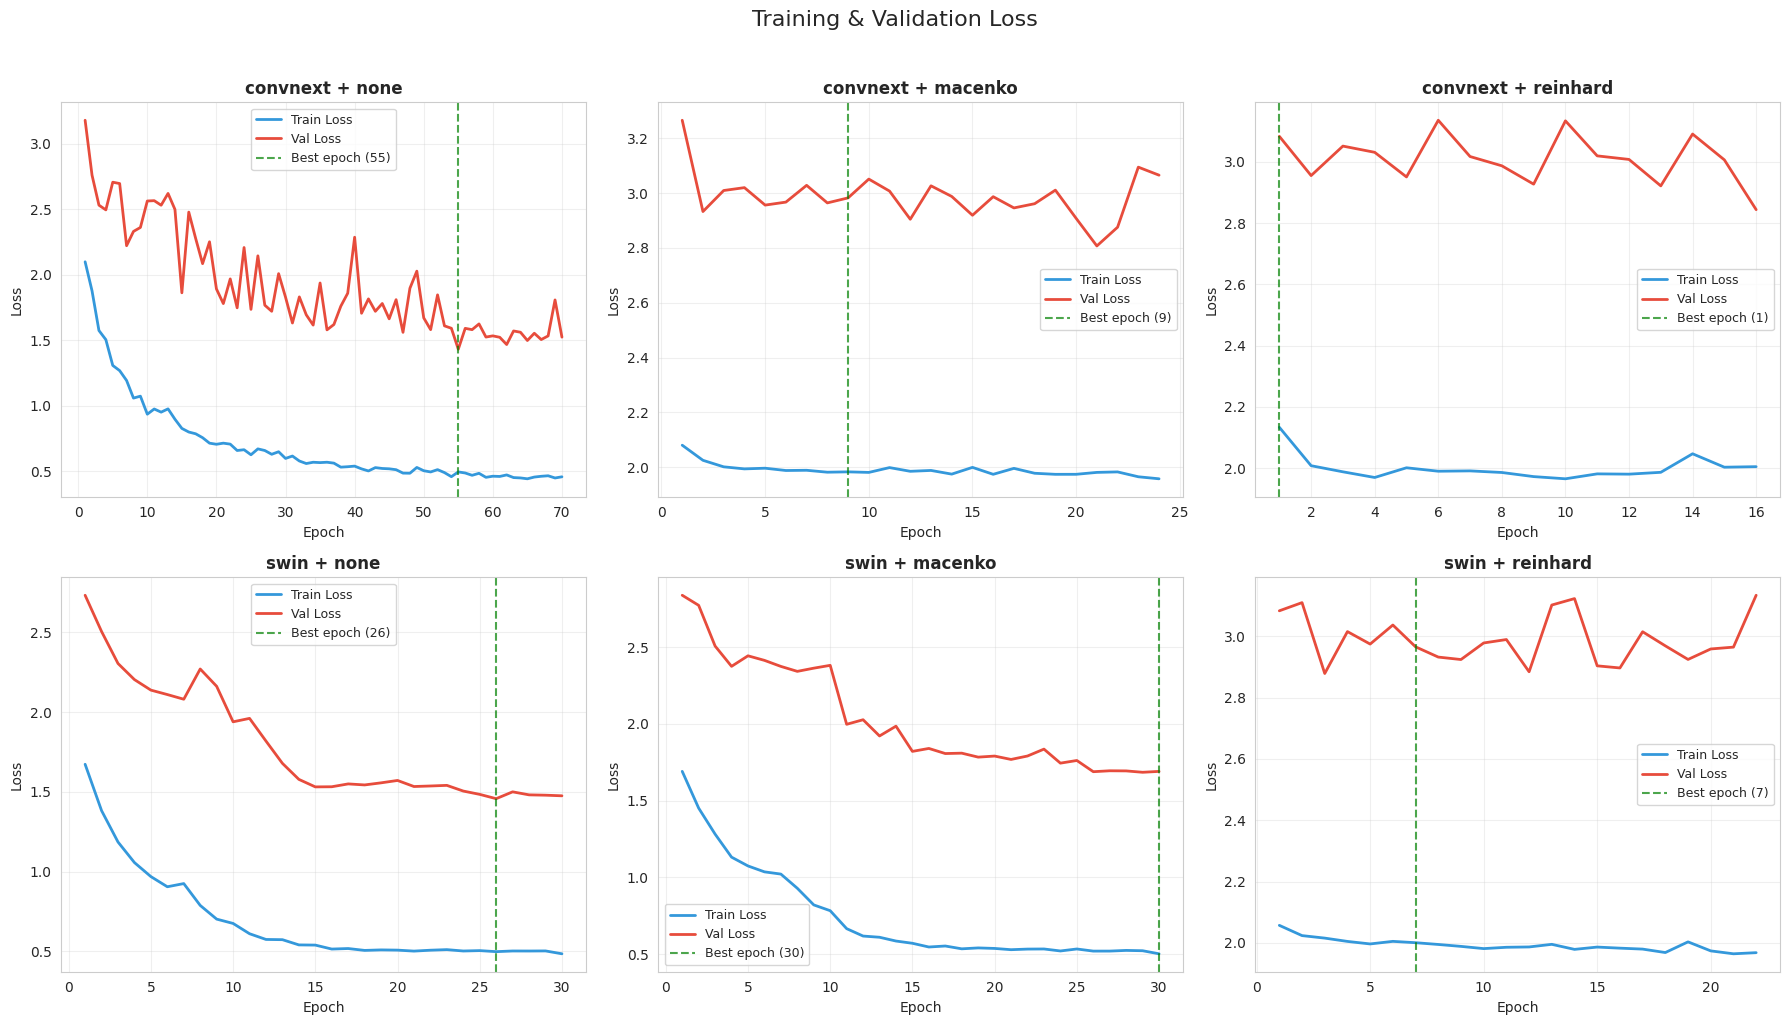

In [13]:
# 3.1 Loss curves - all experiments
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, stain_method in enumerate(STAIN_METHODS):
    for row, model_name in enumerate(MODEL_NAMES):
        ax = axes[row, col]
        exp_name = f"{model_name}_{stain_method}"
        h = all_results[exp_name]["history"]
        
        ax.plot(h["epoch"], h["train_loss"], label="Train Loss", color="#3498db", linewidth=2)
        ax.plot(h["epoch"], h["val_loss"], label="Val Loss", color="#e74c3c", linewidth=2)
        
        best_idx = int(np.argmax(h["val_f1"]))
        ax.axvline(x=h["epoch"][best_idx], color="green", linestyle="--", alpha=0.7, label=f"Best epoch ({h['epoch'][best_idx]})")
        
        ax.set_title(f"{model_name} + {stain_method}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.suptitle("Training & Validation Loss", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "learning_curves_loss.png"), dpi=150, bbox_inches="tight")
plt.show()

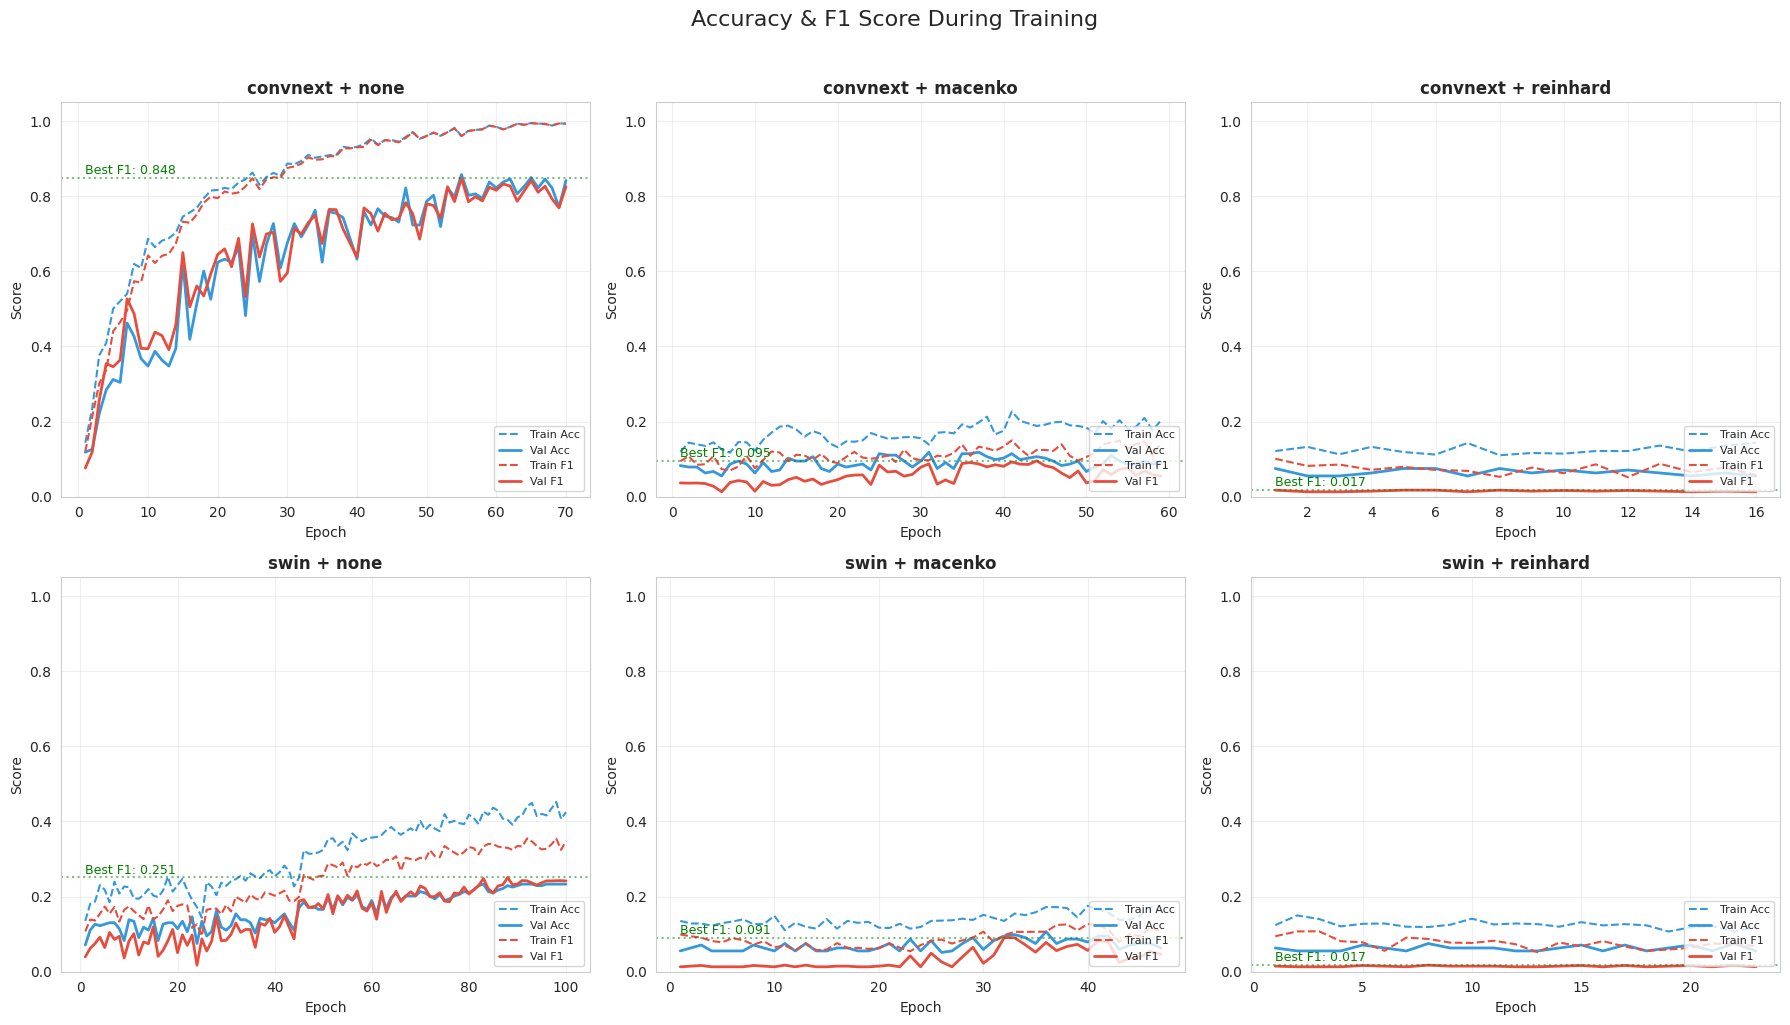

In [ ]:
# 3.2 Accuracy and F1 curves
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, stain_method in enumerate(STAIN_METHODS):
    for row, model_name in enumerate(MODEL_NAMES):
        ax = axes[row, col]
        exp_name = f"{model_name}_{stain_method}"
        h = all_results[exp_name]["history"]
        
        ax.plot(h["epoch"], h["train_acc"], label="Train Acc", color="#3498db", linewidth=1.5, linestyle="--")
        ax.plot(h["epoch"], h["val_acc"], label="Val Acc", color="#3498db", linewidth=2)
        ax.plot(h["epoch"], h["train_f1"], label="Train F1", color="#e74c3c", linewidth=1.5, linestyle="--")
        ax.plot(h["epoch"], h["val_f1"], label="Val F1", color="#e74c3c", linewidth=2)
        
        best_idx = int(np.argmax(h["val_f1"]))
        ax.axhline(y=h["val_f1"][best_idx], color="green", linestyle=":", alpha=0.5)
        ax.text(1, h["val_f1"][best_idx] + 0.01, f"Best F1: {h['val_f1'][best_idx]:.3f}", fontsize=9, color="green")
        
        ax.set_title(f"{model_name} + {stain_method}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8, loc="lower right")
        ax.grid(True, alpha=0.3)
        

plt.suptitle("Accuracy & F1 Score During Training", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "learning_curves_accuracy.png"), dpi=150, bbox_inches="tight")
plt.show()

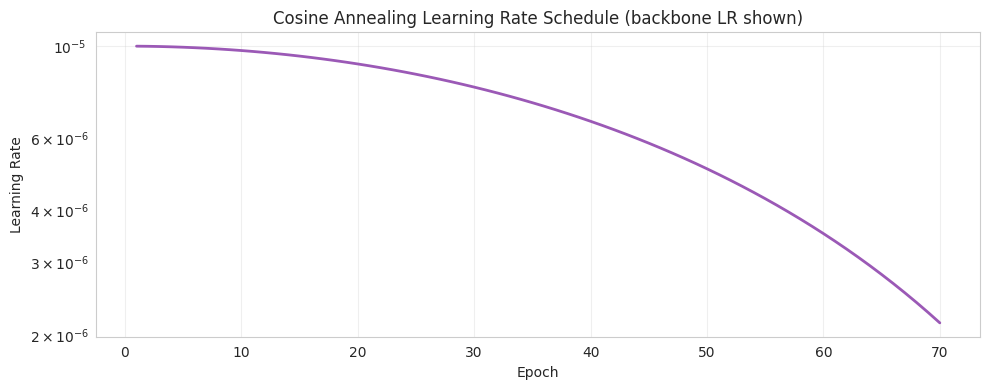

In [10]:
# 3.3 Learning rate schedule
fig, ax = plt.subplots(figsize=(10, 4))

# Just show one experiment's LR curve (they're all the same schedule)
first_exp = list(all_results.keys())[0]
h = all_results[first_exp]["history"]
ax.plot(h["epoch"], h["lr"], color="#9b59b6", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("Cosine Annealing Learning Rate Schedule (backbone LR shown)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "lr_schedule.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. Results Comparison

### Key questions we're answering:
1. **Model comparison**: Is ConvNeXt or Swin better for histopathology?
2. **Stain normalization impact**: Does Macenko/Reinhard help, hurt, or not matter?
3. **Best combination**: Which model + stain method should we use going forward?

In [11]:
# 4.1 Best validation F1 comparison
results_summary = []
for exp_name, result in all_results.items():
    h = result["history"]
    best_idx = int(np.argmax(h["val_f1"]))
    model_name, stain = exp_name.split("_", 1)
    results_summary.append({
        "Model": model_name,
        "Stain Method": stain,
        "Best Val F1": h["val_f1"][best_idx],
        "Best Val Acc": h["val_acc"][best_idx],
        "Best Epoch": h["epoch"][best_idx],
        "Total Epochs": len(h["epoch"]),
        "Final Train Loss": h["train_loss"][-1],
        "Final Val Loss": h["val_loss"][-1],
    })

df_results = pd.DataFrame(results_summary)
df_results = df_results.sort_values("Best Val F1", ascending=False).reset_index(drop=True)
print("\nResults ranked by Best Validation F1:\n")
print(df_results.to_string(index=False))

# Save
df_results.to_csv(os.path.join(RESULTS_DIR, "ablation_study_results.csv"), index=False)


Results ranked by Best Validation F1:

   Model Stain Method  Best Val F1  Best Val Acc  Best Epoch  Total Epochs  Final Train Loss  Final Val Loss
convnext         none     0.847950      0.857708          55            70          0.458085        1.523944
    swin         none     0.250939      0.229249          88           100          1.415448        2.676027
convnext      macenko     0.095432      0.106719          44            59          1.863883        3.400459
    swin      macenko     0.090897      0.094862          32            47          1.937799        2.938533
convnext     reinhard     0.017463      0.075099           1            16          1.966751        3.009979
    swin     reinhard     0.017463      0.075099           8            23          2.018339        3.047767


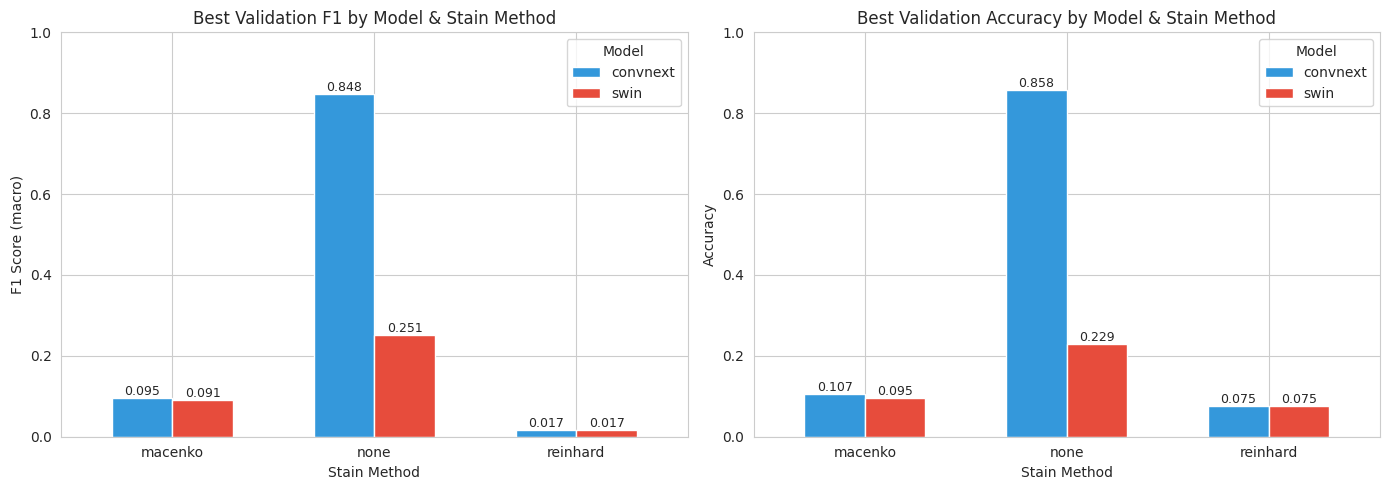

In [12]:
# 4.2 Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 by model and stain method
pivot_f1 = df_results.pivot(index="Stain Method", columns="Model", values="Best Val F1")
pivot_f1.plot(kind="bar", ax=axes[0], color=["#3498db", "#e74c3c"], width=0.6)
axes[0].set_title("Best Validation F1 by Model & Stain Method")
axes[0].set_ylabel("F1 Score (macro)")
axes[0].set_ylim(0, 1)
axes[0].legend(title="Model")
axes[0].tick_params(axis="x", rotation=0)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", fontsize=9)

# Accuracy comparison
pivot_acc = df_results.pivot(index="Stain Method", columns="Model", values="Best Val Acc")
pivot_acc.plot(kind="bar", ax=axes[1], color=["#3498db", "#e74c3c"], width=0.6)
axes[1].set_title("Best Validation Accuracy by Model & Stain Method")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend(title="Model")
axes[1].tick_params(axis="x", rotation=0)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.3f", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ablation_study_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# 4.3 Analyze effects

# Model effect (averaging across stain methods)
print("MODEL EFFECT (averaged across stain methods):")
for model in ["convnext", "swin"]:
    mask = df_results["Model"] == model
    avg_f1 = df_results[mask]["Best Val F1"].mean()
    avg_acc = df_results[mask]["Best Val Acc"].mean()
    print(f"  {model:<12s} Avg F1: {avg_f1:.4f}  Avg Acc: {avg_acc:.4f}")

# Stain effect (averaging across models)
print("\nSTAIN NORMALIZATION EFFECT (averaged across models):")
for stain in STAIN_METHODS:
    mask = df_results["Stain Method"] == stain
    avg_f1 = df_results[mask]["Best Val F1"].mean()
    avg_acc = df_results[mask]["Best Val Acc"].mean()
    print(f"  {stain:<12s} Avg F1: {avg_f1:.4f}  Avg Acc: {avg_acc:.4f}")

# Best overall
best_row = df_results.iloc[0]
print(f"\nBEST COMBINATION: {best_row['Model']} + {best_row['Stain Method']}")
print(f"  F1: {best_row['Best Val F1']:.4f}  Acc: {best_row['Best Val Acc']:.4f}  (epoch {int(best_row['Best Epoch'])})")

MODEL EFFECT (averaged across stain methods):
  convnext     Avg F1: 0.3203  Avg Acc: 0.3465
  swin         Avg F1: 0.1198  Avg Acc: 0.1331

STAIN NORMALIZATION EFFECT (averaged across models):
  none         Avg F1: 0.5494  Avg Acc: 0.5435
  macenko      Avg F1: 0.0932  Avg Acc: 0.1008
  reinhard     Avg F1: 0.0175  Avg Acc: 0.0751

BEST COMBINATION: convnext + none
  F1: 0.8480  Acc: 0.8577  (epoch 55)


## Summary

### What we trained:
- **6 models**: 2 architectures (ConvNeXt, Swin) x 3 stain methods (none, macenko, reinhard)
- All with identical hyperparameters for a fair comparison

### Key outputs saved:
- **Model checkpoints**: `weights/{experiment_name}/best_model.pth` - used in notebooks 04 and 05
- **Training histories**: `results/{experiment_name}/training_history.csv` - the learning curves
- **Ablation results**: `results/ablation_study_results.csv` - the summary table

### What happens next:
- **Notebook 04** (Evaluation): Load the best checkpoint for each experiment and evaluate on the held-out **test set** (which the model has never seen)
- **Notebook 05** (Explainability): Generate XAI explanations and evaluate them quantitatively